<a href="https://colab.research.google.com/github/rizkayantizakaria-cloud/Tugas_Pemodelan-Simulasi/blob/main/LSTM_Hidrodinamika_Plastik_TUGAS1_TERJEMAHAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM untuk Prediksi Konsentrasi Limbah Plastik Berdasarkan Data Hidrodinamika Mingguan

## Tugas Pemodelan Simulasi

Notebook ini merupakan hasil penyelesaian tugas mata kuliah Pemodelan Simulasi. Kode Python pada notebook ini telah dilengkapi dengan komentar (comment) terjemahan dan penjelasan dalam Bahasa Indonesia pada setiap bagian program untuk mempermudah pemahaman terhadap alur kerja model. Selain itu, data telah diolah menjadi data hidrodinamika mingguan dan digunakan untuk membangun, melatih, mengevaluasi, serta melakukan prediksi konsentrasi limbah plastik menggunakan metode Long Short-Term Memory (LSTM).

### Tujuan Notebook
- Menambahkan komentar (comment) terjemahan berbahasa Indonesia pada setiap bagian kode Python.
- Menjelaskan fungsi dari setiap proses dalam program.
- Mengolah data hidrodinamika menjadi data mingguan.
- Membangun dan melatih model LSTM.
- Mengevaluasi performa model menggunakan RMSE, MAE, MAPE, dan R².
- Menampilkan visualisasi hasil prediksi dan analisis residual.
- Melakukan prediksi konsentrasi limbah plastik untuk minggu berikutnya.

## Sel 1 — Install & Import Library

In [1]:
# ============================================================
# INSTALASI DAN IMPORT LIBRARY
# ============================================================

# Menginstal library tambahan yang belum tersedia di Google Colab.
# Opsi --quiet digunakan agar proses instalasi tidak menampilkan
# terlalu banyak informasi di layar.
!pip install seaborn scikit-learn --quiet

# ============================================================
# IMPORT LIBRARY YANG DIGUNAKAN
# ============================================================

# Library untuk perhitungan numerik dan operasi array
import numpy as np

# Library untuk membaca, mengolah, dan memanipulasi data berbentuk tabel
import pandas as pd

# Library untuk membuat grafik visualisasi data
import matplotlib.pyplot as plt

# Library untuk mengatur tata letak beberapa grafik dalam satu tampilan
import matplotlib.gridspec as gridspec

# Library visualisasi statistik dengan tampilan yang lebih menarik
import seaborn as sns

# Library untuk mengatur atau menyembunyikan pesan peringatan (warning)
import warnings

# Library untuk mengakses dan mengelola file maupun folder
import os

# ============================================================
# IMPORT LIBRARY PREPROCESSING DAN EVALUASI MODEL
# ============================================================

# Digunakan untuk melakukan normalisasi data ke rentang 0 sampai 1
from sklearn.preprocessing import MinMaxScaler

# Mengimpor beberapa metrik evaluasi model
from sklearn.metrics import (
    mean_squared_error,            # Menghitung Mean Squared Error (MSE)
    mean_absolute_error,           # Menghitung Mean Absolute Error (MAE)
    r2_score,                      # Menghitung nilai koefisien determinasi (R²)
    mean_absolute_percentage_error # Menghitung Mean Absolute Percentage Error (MAPE)
)

# ============================================================
# IMPORT LIBRARY TENSORFLOW DAN KERAS
# ============================================================

# Mengimpor TensorFlow sebagai framework Deep Learning
import tensorflow as tf

# Mengimpor modul Keras yang terdapat di TensorFlow
from tensorflow import keras

# Mengimpor layer-layer dasar pada Keras
from tensorflow.keras import layers, models, callbacks

# Mengimpor layer yang digunakan dalam pembangunan model LSTM
from tensorflow.keras.layers import (
    LSTM,                 # Layer Long Short-Term Memory
    Dense,                # Layer Fully Connected
    Dropout,              # Layer untuk mengurangi overfitting
    Input,                # Layer input model
    Bidirectional,        # Layer LSTM dua arah
    LayerNormalization    # Layer normalisasi
)

# Mengimpor kelas Model untuk membangun arsitektur jaringan saraf
from tensorflow.keras.models import Model

# ============================================================
# PENGATURAN AWAL PROGRAM
# ============================================================

# Menyembunyikan pesan warning agar tampilan output lebih rapi
warnings.filterwarnings('ignore')

# Menentukan seed agar hasil random NumPy selalu sama
# setiap kali program dijalankan
np.random.seed(42)

# Menentukan seed TensorFlow agar proses pelatihan model
# dapat direproduksi kembali
tf.random.set_seed(42)

# ============================================================
# MENAMPILKAN INFORMASI SISTEM
# ============================================================

# Menampilkan garis pembatas
print('=' * 50)
print('  Konfigurasi Sistem')
print('=' * 50)

# Mengimpor library sys untuk mengetahui informasi Python
import sys

# Menampilkan versi Python yang digunakan
print(f'Python versi   : {sys.version.split()[0]}')

# Menampilkan versi TensorFlow
print(f'TensorFlow     : {tf.__version__}')

# Menampilkan versi NumPy
print(f'NumPy          : {np.__version__}')

# Menampilkan versi Pandas
print(f'Pandas         : {pd.__version__}')

# Mengecek apakah komputer memiliki GPU yang dapat digunakan
gpus = tf.config.list_physical_devices('GPU')

# Menampilkan status penggunaan GPU atau CPU
print(f'GPU tersedia   : {"YA — " + gpus[0].name if gpus else "TIDAK (CPU mode)"}')

# Menampilkan garis penutup
print('=' * 50)

  Konfigurasi Sistem
Python versi   : 3.12.13
TensorFlow     : 2.20.0
NumPy          : 2.0.2
Pandas         : 2.2.2
GPU tersedia   : YA — /physical_device:GPU:0


## Sel 2 — Buat Data Hidrodinamika Sintetis

Data dibuat berdasarkan formula fisik nyata:
- Pasut mengikuti superposisi gelombang M2 dan S2
- Arus dipengaruhi gradien pasut + angin musiman
- Konsentrasi plastik berkorelasi dengan kecepatan arus dan curah hujan

In [3]:
def buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
):
    """
    Membuat dataset hidrodinamika sintetis realistis.

    Parameter:
    - tanggal_mulai : string 'YYYY-MM-DD'
    - n_hari        : jumlah hari data (default 365 = 1 tahun)
    - resolusi_jam  : interval data dalam jam (1 = per jam)

    Return:
    - df : DataFrame dengan semua variabel hidrodinamika
    """

    # Buat index waktu
    n_titik = n_hari * 24 // resolusi_jam
    waktu   = pd.date_range(
        start=tanggal_mulai,
        periods=n_titik,
        freq=f'{resolusi_jam}h'
    )
    t = np.arange(n_titik)  # indeks waktu integer

    print(f'Membuat {n_titik:,} baris data ({n_hari} hari, resolusi {resolusi_jam} jam)...')

    # ============================================================
    # 1. PASUT (Tidal Height)
    # Superposisi komponen M2 (12.42 jam) + S2 (12.00 jam)
    # + komponen K1 (23.93 jam) untuk pola diurnal
    # ============================================================
    T_M2  = 12.42  # periode komponen utama pasut (jam)
    T_S2  = 12.00  # komponen solar semi-diurnal
    T_K1  = 23.93  # komponen lunisolar diurnal

    noise_pasut   = np.random.normal(0, 0.05, n_titik)
    tinggi_pasut  = (
        1.20 * np.sin(2 * np.pi * t / T_M2) +
        0.45 * np.sin(2 * np.pi * t / T_S2 + np.pi/6) +
        0.25 * np.sin(2 * np.pi * t / T_K1) +
        noise_pasut
    )

    # ============================================================
    # 2. ARUS LAUT (U dan V komponen)
    # Arus utama driven by pasut + pengaruh angin musiman
    # ============================================================
    T_musim = 365.25 * 24  # periode musiman (jam)

    # Arus komponen U (timur-barat), dipengaruhi gradien pasut
    u_arus = (
        0.35 * np.cos(2 * np.pi * t / T_M2) +
        0.12 * np.cos(2 * np.pi * t / T_S2) +
        0.08 * np.sin(2 * np.pi * t / T_musim) +  # variasi musiman
        np.random.normal(0, 0.04, n_titik)
    )

    # Arus komponen V (utara-selatan)
    v_arus = (
        0.28 * np.sin(2 * np.pi * t / T_M2 + np.pi/4) +
        0.10 * np.sin(2 * np.pi * t / T_S2) +
        0.06 * np.cos(2 * np.pi * t / T_musim) +
        np.random.normal(0, 0.03, n_titik)
    )

    # Magnitude arus (resultant)
    mag_arus = np.sqrt(u_arus**2 + v_arus**2)

    # ============================================================
    # 3. GELOMBANG LAUT
    # Tinggi signifikan (Hs) dan periode puncak (Tp)
    # Lebih tinggi di musim barat (bulan 11-3)
    # ============================================================
    bulan = waktu.month.values

    # Faktor musim: musim barat lebih bergelombang
    faktor_musim = np.where(
        (bulan >= 11) | (bulan <= 3),
        1.8,   # musim barat
        1.0    # musim timur/peralihan
    )

    Hs = (
        faktor_musim * 0.6 *
        (1 + 0.3 * np.sin(2 * np.pi * t / (6 * 24))) +  # variasi 6 harian
        np.abs(np.random.normal(0, 0.15, n_titik))
    )
    Hs = np.clip(Hs, 0.05, 4.5)  # batas fisik realistis

    Tp = 4.5 + 2.5 * (Hs / Hs.max()) + np.random.normal(0, 0.5, n_titik)
    Tp = np.clip(Tp, 3.0, 14.0)

    # ============================================================
    # 4. ANGIN
    # Pola musim barat (NW) dan musim timur (SE) khas Indonesia
    # ============================================================
    kec_angin = (
        faktor_musim * 3.5 +
        1.5 * np.sin(2 * np.pi * t / (12 * 24)) +  # variasi diurnal angin darat-laut
        np.abs(np.random.normal(0, 0.8, n_titik))
    )
    kec_angin = np.clip(kec_angin, 0.5, 18.0)

    # Arah angin: musim barat ~315° (NW), musim timur ~135° (SE)
    arah_base = np.where(
        (bulan >= 11) | (bulan <= 3),
        315.0,  # musim barat
        135.0   # musim timur
    )
    arah_angin = (arah_base + np.random.normal(0, 25, n_titik)) % 360

    # Encoding sirkular arah angin
    angin_sin = np.sin(np.radians(arah_angin))
    angin_cos = np.cos(np.radians(arah_angin))

    # ============================================================
    # 5. CURAH HUJAN
    # Musim hujan (Nov-Mar), musim kemarau (Jun-Sep)
    # ============================================================
    intensitas_hujan = np.where(
        (bulan >= 11) | (bulan <= 3),
        0.4,   # peluang hujan lebih tinggi musim basah
        0.12   # peluang hujan lebih rendah musim kemarau
    )

    # Simulasi kejadian hujan diskrit
    kejadian_hujan = np.random.random(n_titik) < intensitas_hujan / resolusi_jam
    curah_hujan = np.where(
        kejadian_hujan,
        np.abs(np.random.exponential(8.0, n_titik)),  # intensitas eksponensial
        0.0
    )
    # Akumulasi hujan menjadi sedikit lebih smooth
    curah_hujan = pd.Series(curah_hujan).rolling(3, min_periods=1).mean().values

    # ============================================================
    # 6. KONSENTRASI PLASTIK (TARGET)
    # Dipengaruhi oleh: arus kuat, hujan deras, pasut rendah
    # + tren musiman + noise acak lapangan
    # ============================================================

    # Base: konsentrasi rata-rata ~250 partikel/m³
    base_plastik = 250.0

    # Kontribusi setiap faktor
    efek_arus    = 180 * mag_arus               # arus kuat mobilisasi plastik
    efek_hujan   = 25  * np.log1p(curah_hujan)  # hujan bawa plastik dari daratan
    efek_pasut   = -60 * tinggi_pasut           # pasut tinggi = pengenceran
    efek_musim   = 80  * np.sin(2 * np.pi * t / T_musim + np.pi)  # puncak di musim hujan
    efek_gelombang = 30 * Hs                    # gelombang aduk plastik permukaan

    # Lag effect: plastik tidak langsung muncul saat hujan (delay 3-6 jam)
    lag_hujan = pd.Series(efek_hujan).shift(4).fillna(0).values

       # Menggabungkan seluruh faktor yang memengaruhi
    # konsentrasi plastik di laut
    konsentrasi_plastik = (
        base_plastik +
        efek_arus +
        lag_hujan +
        efek_pasut +
        efek_musim +
        efek_gelombang +
        np.random.normal(0, 30, n_titik)  # Menambahkan noise acak agar data lebih realistis
    )

    # Membatasi nilai konsentrasi plastik agar tidak bernilai negatif
    konsentrasi_plastik = np.clip(konsentrasi_plastik, 10.0, 1200.0)

    # ============================================================
    # 7. MEMBUAT FITUR WAKTU
    # ============================================================

    # Mengambil informasi jam dan bulan dari indeks waktu
    jam = waktu.hour.values
    bulan_val = waktu.month.values

    # Mengubah informasi jam menjadi bentuk sinus dan cosinus
    # agar pola waktu bersifat sirkular dan mudah dipelajari model
    jam_sin = np.sin(2 * np.pi * jam / 24)
    jam_cos = np.cos(2 * np.pi * jam / 24)

    # Mengubah informasi bulan menjadi bentuk sinus dan cosinus
    # untuk merepresentasikan pola musiman
    bulan_sin = np.sin(2 * np.pi * bulan_val / 12)
    bulan_cos = np.cos(2 * np.pi * bulan_val / 12)

    # ============================================================
    # 8. MENYUSUN DATA KE DALAM DATAFRAME
    # ============================================================

    # Menggabungkan seluruh variabel hidrodinamika
    # ke dalam sebuah DataFrame
    df = pd.DataFrame({
        'datetime'             : waktu,
        'tinggi_pasut'         : np.round(tinggi_pasut, 3),
        'u_arus'               : np.round(u_arus, 4),
        'v_arus'               : np.round(v_arus, 4),
        'mag_arus'             : np.round(mag_arus, 4),
        'Hs_gelombang'         : np.round(Hs, 3),
        'Tp_gelombang'         : np.round(Tp, 2),
        'kec_angin'            : np.round(kec_angin, 2),
        'arah_angin'           : np.round(arah_angin, 1),
        'angin_sin'            : np.round(angin_sin, 4),
        'angin_cos'            : np.round(angin_cos, 4),
        'curah_hujan'          : np.round(curah_hujan, 2),
        'jam_sin'              : np.round(jam_sin, 4),
        'jam_cos'              : np.round(jam_cos, 4),
        'bulan_sin'            : np.round(bulan_sin, 4),
        'bulan_cos'            : np.round(bulan_cos, 4),
        'konsentrasi_plastik'  : np.round(konsentrasi_plastik, 2),
    })

    # Menjadikan kolom datetime sebagai indeks DataFrame
    # agar data tersusun berdasarkan waktu
    df = df.set_index('datetime')

    # Mengembalikan DataFrame sebagai hasil fungsi
    return df


# ============================================================
# MEMBUAT DATASET HIDRODINAMIKA
# ============================================================

# Memanggil fungsi untuk membuat dataset hidrodinamika sintetis
# dengan periode selama 1 tahun dan resolusi data setiap 1 jam.
df = buat_data_hidrodinamika(
    tanggal_mulai='2025-01-01',
    n_hari=365,
    resolusi_jam=1
)

# ============================================================
# MENGUBAH DATA MENJADI DATA MINGGUAN
# ============================================================

# Mengelompokkan data berdasarkan minggu
# kemudian menghitung nilai rata-rata setiap variabel.
df_mingguan = df.resample('W').mean()

# Menambahkan kolom nomor minggu
# agar lebih mudah digunakan saat analisis.
df_mingguan['minggu_ke'] = range(1, len(df_mingguan) + 1)

# ============================================================
# MENYIMPAN DATASET
# ============================================================

# Menyimpan dataset dengan resolusi per jam
# ke dalam file CSV.
df.to_csv('data_hidrodinamika_sintetis.csv')

# Menyimpan dataset mingguan
# ke dalam file CSV terpisah.
df_mingguan.to_csv('data_hidrodinamika_mingguan.csv')

# ============================================================
# MENAMPILKAN INFORMASI DATASET
# ============================================================

# Menampilkan informasi bahwa proses pembuatan
# dataset telah selesai.
print('\nDataset berhasil dibuat!')

# Menampilkan jumlah data pada dataset harian.
print(f'Data harian   : {df.shape[0]:,} baris')

# Menampilkan jumlah data pada dataset mingguan.
print(f'Data mingguan : {df_mingguan.shape[0]} minggu')

# Menampilkan jumlah kolom pada dataset mingguan.
print(f'Jumlah kolom  : {df_mingguan.shape[1]}')

# Menampilkan rentang waktu data.
print(f'Periode       : {df_mingguan.index[0].date()} sampai {df_mingguan.index[-1].date()}')

# Mengecek apakah masih terdapat nilai yang hilang (missing value).
print(f'Missing values: {df_mingguan.isnull().sum().sum()}')

# Menampilkan lima baris pertama dataset mingguan
# sebagai contoh hasil yang telah dibuat.
print('\nLima minggu pertama')
print(df_mingguan.head().to_string())

Membuat 8,760 baris data (365 hari, resolusi 1 jam)...

Dataset berhasil dibuat!
Data harian   : 8,760 baris
Data mingguan : 53 minggu
Jumlah kolom  : 17
Periode       : 2025-01-05 sampai 2026-01-04
Missing values: 0

Lima minggu pertama
            tinggi_pasut    u_arus    v_arus  mag_arus  Hs_gelombang  Tp_gelombang  kec_angin  arah_angin  angin_sin  angin_cos  curah_hujan       jam_sin  jam_cos  bulan_sin  bulan_cos  konsentrasi_plastik  minggu_ke
datetime                                                                                                                                                                                                                 
2025-01-05      0.028833  0.002482  0.065107  0.388002      1.232900      6.184833   7.974250  302.676667  -0.578849   0.708768     2.786583  4.625929e-19      0.0   0.500000   0.866000           371.906083          1
2025-01-12     -0.011905  0.020475  0.056714  0.257038      1.176685      6.131667   6.165298  300.403571  -

## Sel 3 — Statistik Deskriptif

In [4]:
# ============================================================
# MENAMPILKAN STATISTIK DESKRIPTIF DATASET
# ============================================================

# Menampilkan judul statistik deskriptif dataset hidrodinamika
print('Statistik Deskriptif Dataset Hidrodinamika:')
print('=' * 70)

# Menghitung statistik deskriptif setiap variabel
# kemudian mentransposisikannya agar lebih mudah dibaca
stats = df.describe().T

# Menghitung rentang nilai (range),
# yaitu selisih antara nilai maksimum dan minimum
stats['range'] = stats['max'] - stats['min']

# Menampilkan nilai rata-rata, standar deviasi,
# nilai minimum, maksimum, dan rentang setiap variabel
print(stats[['mean', 'std', 'min', 'max', 'range']].round(3).to_string())

# ============================================================
# MENAMPILKAN KORELASI FITUR DENGAN TARGET
# ============================================================

# Menampilkan judul analisis korelasi
print('\nKorelasi dengan Konsentrasi Plastik (Target):')
print('-' * 40)

# Menghitung nilai korelasi setiap variabel
# terhadap variabel target (konsentrasi plastik),
# kemudian mengurutkannya dari yang terbesar
korelasi = df.corr()['konsentrasi_plastik'].sort_values(ascending=False)

# Menampilkan nilai korelasi setiap fitur
# beserta visualisasi sederhana menggunakan karakter '#'
for fitur, nilai in korelasi.items():

    # Melewati variabel target agar tidak dibandingkan dengan dirinya sendiri
    if fitur != 'konsentrasi_plastik':

        # Membuat panjang batang berdasarkan besar nilai korelasi
        bar = '#' * int(abs(nilai) * 20)

        # Menentukan tanda positif atau negatif korelasi
        arah = '+' if nilai >= 0 else '-'

        # Menampilkan nama fitur, nilai korelasi,
        # serta diagram batang sederhana
        print(f'  {fitur:25s}: {arah}{abs(nilai):.3f}  {bar}')

Statistik Deskriptif Dataset Hidrodinamika:
                        mean     std     min      max    range
tinggi_pasut           0.001   0.921  -1.942    1.970    3.912
u_arus                -0.000   0.270  -0.589    0.609    1.198
v_arus                 0.000   0.216  -0.488    0.518    1.007
mag_arus               0.323   0.125   0.003    0.660    0.657
Hs_gelombang           0.919   0.309   0.422    1.873    1.451
Tp_gelombang           5.723   0.648   3.540    8.090    4.550
kec_angin              5.317   1.828   2.010   10.240    8.230
arah_angin           204.005  93.313   0.100  359.800  359.700
angin_sin              0.115   0.700  -1.000    1.000    2.000
angin_cos             -0.108   0.697  -1.000    1.000    2.000
curah_hujan            1.895   3.092   0.000   22.520   22.520
jam_sin                0.000   0.707  -1.000    1.000    2.000
jam_cos               -0.000   0.707  -1.000    1.000    2.000
bulan_sin             -0.005   0.706  -1.000    1.000    2.000
bulan_cos  

## Sel 4 — Visualisasi Data (EDA)

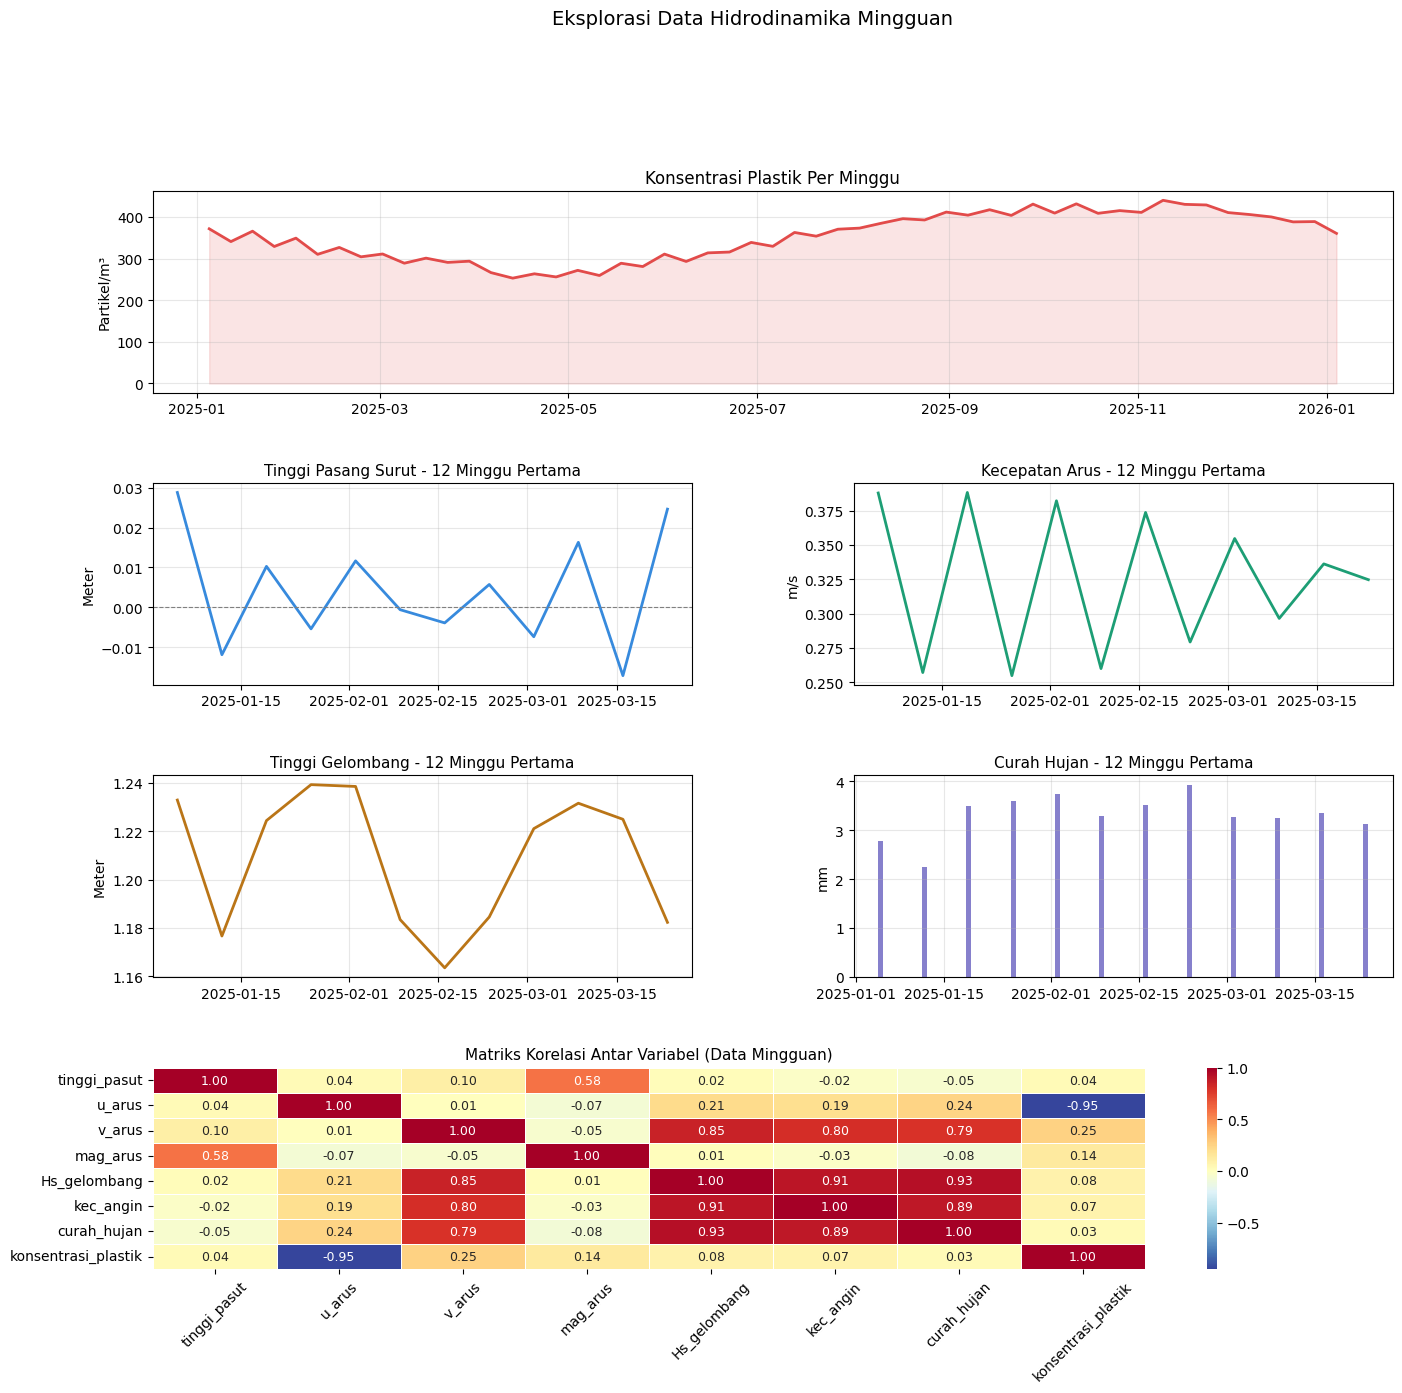

Visualisasi EDA data mingguan selesai!


In [5]:
# ============================================================
# MEMBUAT VISUALISASI EXPLORATORY DATA ANALYSIS (EDA)
# DATA HIDRODINAMIKA MINGGUAN
# ============================================================

# Membuat kanvas gambar dengan ukuran 16 × 14 inci
fig = plt.figure(figsize=(16, 14))

# Membuat tata letak grafik menggunakan GridSpec
# yang terdiri dari 4 baris dan 2 kolom
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

# Mengambil data 12 minggu pertama
# agar perubahan data lebih mudah diamati
df_12 = df_mingguan.iloc[:12]

# ============================================================
# 1. GRAFIK KONSENTRASI PLASTIK PER MINGGU
# ============================================================

# Membuat area grafik pertama
ax1 = fig.add_subplot(gs[0, :])

# Menampilkan grafik konsentrasi plastik mingguan
ax1.plot(
    df_mingguan.index,
    df_mingguan['konsentrasi_plastik'],
    color='#E24B4A',
    lw=2
)

# Memberikan warna pada area di bawah grafik
ax1.fill_between(
    df_mingguan.index,
    df_mingguan['konsentrasi_plastik'],
    alpha=0.15,
    color='#E24B4A'
)

# Memberikan judul grafik
ax1.set_title('Konsentrasi Plastik Per Minggu', fontsize=12)

# Memberikan label sumbu Y
ax1.set_ylabel('Partikel/m³')

# Menampilkan grid
ax1.grid(True, alpha=0.3)

# ============================================================
# 2. GRAFIK TINGGI PASANG SURUT 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik kedua
ax2 = fig.add_subplot(gs[1, 0])

# Menampilkan grafik tinggi pasang surut
ax2.plot(
    df_12.index,
    df_12['tinggi_pasut'],
    color='#378ADD',
    lw=2
)

# Menambahkan garis nol sebagai acuan
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Memberikan judul grafik
ax2.set_title('Tinggi Pasang Surut - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax2.set_ylabel('Meter')

# Menampilkan grid
ax2.grid(True, alpha=0.3)

# ============================================================
# 3. GRAFIK KECEPATAN ARUS 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik ketiga
ax3 = fig.add_subplot(gs[1, 1])

# Menampilkan grafik kecepatan arus
ax3.plot(
    df_12.index,
    df_12['mag_arus'],
    color='#1D9E75',
    lw=2
)

# Memberikan judul grafik
ax3.set_title('Kecepatan Arus - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax3.set_ylabel('m/s')

# Menampilkan grid
ax3.grid(True, alpha=0.3)

# ============================================================
# 4. GRAFIK TINGGI GELOMBANG 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik keempat
ax4 = fig.add_subplot(gs[2, 0])

# Menampilkan grafik tinggi gelombang
ax4.plot(
    df_12.index,
    df_12['Hs_gelombang'],
    color='#BA7517',
    lw=2
)

# Memberikan judul grafik
ax4.set_title('Tinggi Gelombang - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax4.set_ylabel('Meter')

# Menampilkan grid
ax4.grid(True, alpha=0.3)

# ============================================================
# 5. GRAFIK CURAH HUJAN 12 MINGGU PERTAMA
# ============================================================

# Membuat area grafik kelima
ax5 = fig.add_subplot(gs[2, 1])

# Menampilkan grafik batang curah hujan mingguan
ax5.bar(
    df_12.index,
    df_12['curah_hujan'],
    color='#534AB7',
    alpha=0.7
)

# Memberikan judul grafik
ax5.set_title('Curah Hujan - 12 Minggu Pertama', fontsize=11)

# Memberikan label sumbu Y
ax5.set_ylabel('mm')

# Menampilkan grid
ax5.grid(True, alpha=0.3)

# ============================================================
# 6. HEATMAP KORELASI ANTAR VARIABEL
# ============================================================

# Membuat area grafik keenam
ax6 = fig.add_subplot(gs[3, :])

# Menentukan variabel yang akan dihitung korelasinya
fitur_korelasi = [
    'tinggi_pasut',
    'u_arus',
    'v_arus',
    'mag_arus',
    'Hs_gelombang',
    'kec_angin',
    'curah_hujan',
    'konsentrasi_plastik'
]

# Menghitung matriks korelasi dari data mingguan
corr_matrix = df_mingguan[fitur_korelasi].corr()

# Menampilkan heatmap korelasi
sns.heatmap(
    corr_matrix,
    ax=ax6,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    annot_kws={'size':9}
)

# Memberikan judul heatmap
ax6.set_title('Matriks Korelasi Antar Variabel (Data Mingguan)', fontsize=11)

# Memutar label sumbu X
ax6.tick_params(axis='x', rotation=45)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN HASIL VISUALISASI
# ============================================================

# Memberikan judul utama pada seluruh grafik
plt.suptitle(
    'Eksplorasi Data Hidrodinamika Mingguan',
    fontsize=14,
    y=1.01
)

# Menyimpan hasil visualisasi
plt.savefig(
    'eda_hidrodinamika_mingguan.png',
    bbox_inches='tight',
    dpi=150
)

# Menampilkan seluruh grafik
plt.show()

# Menampilkan pesan bahwa visualisasi telah selesai
print('Visualisasi EDA data mingguan selesai!')

## Sel 5 — Preprocessing: Normalisasi & Sliding Window

In [7]:
# ============================================================
# MENENTUKAN FITUR INPUT DAN TARGET
# ============================================================

# Daftar variabel (fitur) yang akan digunakan sebagai input
# pada model LSTM. Seluruh variabel ini menjadi informasi
# yang digunakan model untuk memprediksi konsentrasi plastik.
FITUR_INPUT = [
    'tinggi_pasut',            # Tinggi muka air laut akibat pasang surut
    'u_arus',                  # Komponen arus arah timur-barat
    'v_arus',                  # Komponen arus arah utara-selatan
    'mag_arus',                # Besar (magnitudo) kecepatan arus
    'Hs_gelombang',            # Tinggi gelombang signifikan
    'Tp_gelombang',            # Periode puncak gelombang
    'kec_angin',               # Kecepatan angin
    'angin_sin',               # Encoding sinus arah angin
    'angin_cos',               # Encoding cosinus arah angin
    'curah_hujan',             # Curah hujan
    'konsentrasi_plastik'      # Nilai konsentrasi plastik sebelumnya
                                # digunakan sebagai input autoregressive
]

# Menentukan variabel target yang akan diprediksi model.
# Dalam penelitian ini targetnya adalah konsentrasi plastik laut.
TARGET = 'konsentrasi_plastik'

# ============================================================
# MENENTUKAN PARAMETER SLIDING WINDOW
# ============================================================

# Menentukan banyaknya data historis yang digunakan
# sebagai input model LSTM.
# WINDOW = 4 berarti model menggunakan data
# dari 4 minggu terakhir.
WINDOW = 4

# Menentukan jumlah periode yang akan diprediksi.
# HORIZON = 1 berarti model memprediksi
# konsentrasi plastik untuk 1 minggu berikutnya.
HORIZON = 1

# Menampilkan informasi parameter yang digunakan.
print(f'Jumlah fitur input : {len(FITUR_INPUT)} variabel')
print(f'Window size        : {WINDOW} minggu')
print(f'Horizon            : {HORIZON} minggu')

# ============================================================
# NORMALISASI DATA MENGGUNAKAN MIN-MAX SCALER
# ============================================================

# Membuat objek Min-Max Scaler untuk fitur input.
# Seluruh nilai fitur akan diubah ke rentang 0 sampai 1.
scaler_X = MinMaxScaler(feature_range=(0, 1))

# Membuat Min-Max Scaler khusus untuk target.
# Target dipisahkan agar proses inverse transform
# lebih mudah dilakukan setelah prediksi.
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Mengambil seluruh variabel input dari dataset mingguan.
X_data = df_mingguan[FITUR_INPUT].values

# Mengambil variabel target dari dataset mingguan.
y_data = df_mingguan[[TARGET]].values

# Melakukan normalisasi terhadap seluruh fitur input.
X_scaled = scaler_X.fit_transform(X_data)

# Melakukan normalisasi terhadap variabel target.
y_scaled = scaler_y.fit_transform(y_data)

# Menampilkan rentang nilai setelah proses normalisasi.
print('\nRentang data setelah normalisasi')

print(f'Input  : {X_scaled.min():.4f} - {X_scaled.max():.4f}')
print(f'Target : {y_scaled.min():.4f} - {y_scaled.max():.4f}')

# ============================================================
# MEMBUAT DATA SEQUENCE UNTUK MODEL LSTM
# ============================================================

def buat_sequences(X, y, window, horizon):
    """
    Fungsi ini mengubah data deret waktu menjadi
    sequence (urutan data) yang dapat diproses oleh LSTM.

    Parameter
    ---------
    X : Data fitur yang telah dinormalisasi.
    y : Data target yang telah dinormalisasi.
    window : Jumlah data historis yang digunakan.
    horizon : Jumlah langkah prediksi ke depan.

    Hasil
    -----
    Xs : Data input berbentuk
         (jumlah_sampel, window, jumlah_fitur)

    ys : Data target berbentuk
         (jumlah_sampel, horizon)
    """

    # Menyimpan sequence input.
    Xs = []

    # Menyimpan target setiap sequence.
    ys = []

    # Menghitung jumlah sequence yang dapat dibuat.
    total = len(X) - window - horizon + 1

    # Membentuk sequence menggunakan teknik
    # sliding window.
    for i in range(total):

        # Mengambil data historis sebanyak WINDOW minggu.
        Xs.append(X[i:i + window])

        # Mengambil target pada minggu berikutnya.
        ys.append(y[i + window:i + window + horizon, 0])

    # Mengubah list menjadi array NumPy.
    return np.array(Xs), np.array(ys)

# Membentuk sequence input dan target
# yang siap digunakan oleh model LSTM.
X_seq, y_seq = buat_sequences(
    X_scaled,
    y_scaled,
    WINDOW,
    HORIZON
)

# Menampilkan ukuran data sequence.
print('\nUkuran sequence')

print(f'X_seq : {X_seq.shape}')
print(f'y_seq : {y_seq.shape}')

# ============================================================
# MEMBAGI DATA MENJADI TRAINING, VALIDATION, DAN TESTING
# ============================================================

# Menghitung jumlah total sequence.
n = len(X_seq)

# Menentukan 70% data sebagai training.
n_train = int(n * 0.70)

# Menentukan 15% data sebagai validation.
n_val = int(n * 0.15)

# Sisa data (15%) digunakan sebagai testing.

# -------------------------------
# Data Training
# -------------------------------
X_train = X_seq[:n_train]
y_train = y_seq[:n_train]

# -------------------------------
# Data Validation
# -------------------------------
X_val = X_seq[n_train:n_train + n_val]
y_val = y_seq[n_train:n_train + n_val]

# -------------------------------
# Data Testing
# -------------------------------
X_test = X_seq[n_train + n_val:]
y_test = y_seq[n_train + n_val:]

# Menampilkan jumlah sampel pada
# masing-masing kelompok data.
print('\nPembagian Dataset')

print(f'Training   : {X_train.shape[0]} sampel')

print(f'Validation : {X_val.shape[0]} sampel')

print(f'Testing    : {X_test.shape[0]} sampel')

Jumlah fitur input : 11 variabel
Window size        : 4 minggu
Horizon            : 1 minggu

Rentang data setelah normalisasi
Input  : 0.0000 - 1.0000
Target : 0.0000 - 1.0000

Ukuran sequence
X_seq : (49, 4, 11)
y_seq : (49, 1)

Pembagian Dataset
Training   : 34 sampel
Validation : 7 sampel
Testing    : 8 sampel


## Sel 6 — Bangun Model LSTM

In [9]:
# ============================================================
# MEMBANGUN MODEL LSTM UNTUK PREDIKSI KONSENTRASI PLASTIK
# BERDASARKAN DATA HIDRODINAMIKA MINGGUAN
# ============================================================

def build_lstm_hidrodinamika(n_fitur, window, horizon):
    """
    Fungsi untuk membangun arsitektur model
    Bidirectional Long Short-Term Memory (Bi-LSTM)
    yang digunakan untuk memprediksi konsentrasi
    plastik laut berdasarkan data hidrodinamika.

    Parameter
    ----------
    n_fitur : int
        Jumlah variabel input yang digunakan.

    window : int
        Banyaknya data historis (minggu) yang
        digunakan sebagai input model.

    horizon : int
        Jumlah minggu yang akan diprediksi.

    Arsitektur Model
    ----------------
    Input
        ↓
    Bidirectional LSTM (32 neuron)
        ↓
    Layer Normalization
        ↓
    LSTM (16 neuron)
        ↓
    Layer Normalization
        ↓
    LSTM (8 neuron)
        ↓
    Dropout
        ↓
    Dense (16 neuron)
        ↓
    Dropout
        ↓
    Dense (8 neuron)
        ↓
    Output Prediksi
    """

    # ============================================================
    # INPUT LAYER
    # ============================================================

    # Mendefinisikan bentuk data yang akan diterima model.
    # Shape terdiri atas:
    # (window, jumlah fitur)
    inp = Input(
        shape=(window, n_fitur),
        name='input_hidrodinamika'
    )

    # ============================================================
    # LAYER 1
    # ============================================================

    # Menggunakan Bidirectional LSTM sehingga model
    # dapat mempelajari hubungan data dari arah maju
    # dan arah mundur secara bersamaan.
    x = Bidirectional(
        LSTM(
            32,                     # Jumlah neuron
            return_sequences=True,  # Output diteruskan ke layer berikutnya
            dropout=0.10,           # Dropout pada input LSTM
            recurrent_dropout=0.05  # Dropout pada recurrent state
        ),
        name='bilstm_1'
    )(inp)

    # Menormalkan output layer agar proses training
    # menjadi lebih stabil dan cepat konvergen.
    x = LayerNormalization(
        name='ln_1'
    )(x)

    # ============================================================
    # LAYER 2
    # ============================================================

    # Layer LSTM kedua bertugas mempelajari pola
    # temporal yang lebih kompleks.
    x = LSTM(
        16,
        return_sequences=True,
        dropout=0.10,
        name='lstm_2'
    )(x)

    # Menormalkan kembali output layer kedua.
    x = LayerNormalization(
        name='ln_2'
    )(x)

    # ============================================================
    # LAYER 3
    # ============================================================

    # Layer LSTM terakhir menghasilkan representasi
    # akhir dari data time series.
    # return_sequences=False berarti hanya output
    # terakhir yang diteruskan.
    x = LSTM(
        8,
        return_sequences=False,
        dropout=0.10,
        name='lstm_3'
    )(x)

    # Dropout digunakan untuk mengurangi risiko
    # overfitting selama proses pelatihan.
    x = Dropout(
        0.20,
        name='dropout_1'
    )(x)

    # ============================================================
    # FULLY CONNECTED LAYER
    # ============================================================

    # Dense layer pertama berfungsi mempelajari
    # hubungan nonlinier dari hasil ekstraksi fitur LSTM.
    x = Dense(
        16,
        activation='relu',
        name='dense_1'
    )(x)

    # Dropout tambahan sebagai regularisasi.
    x = Dropout(
        0.10,
        name='dropout_2'
    )(x)

    # Dense layer kedua melakukan penyempurnaan
    # representasi fitur sebelum prediksi akhir.
    x = Dense(
        8,
        activation='relu',
        name='dense_2'
    )(x)

    # ============================================================
    # OUTPUT LAYER
    # ============================================================

    # Layer output menghasilkan nilai prediksi
    # konsentrasi plastik.
    #
    # Aktivasi linear digunakan karena
    # permasalahan ini merupakan regresi.
    output = Dense(
        horizon,
        activation='linear',
        name='output_prediksi'
    )(x)

    # Membentuk model akhir dengan input dan output
    # yang telah didefinisikan sebelumnya.
    model = Model(
        inputs=inp,
        outputs=output,
        name='LSTM_Hidrodinamika_Mingguan'
    )

    # Mengembalikan model yang telah dibuat.
    return model


# ============================================================
# MEMBANGUN MODEL
# ============================================================

# Mengambil jumlah fitur input dari data training.
# X_train memiliki bentuk:
# (jumlah_sampel, window, jumlah_fitur)
n_fitur = X_train.shape[2]

# Membuat model menggunakan fungsi
# build_lstm_hidrodinamika().
model = build_lstm_hidrodinamika(
    n_fitur,
    WINDOW,
    HORIZON
)

# ============================================================
# MENGOMPILASI MODEL
# ============================================================

# Menentukan konfigurasi proses pelatihan model.
model.compile(

    # Optimizer Adam digunakan karena mampu
    # mempercepat proses konvergensi model.
    optimizer=keras.optimizers.Adam(

        # Learning rate menentukan besar langkah
        # pembaruan bobot setiap iterasi.
        learning_rate=0.001,

        # Clipnorm membatasi nilai gradien
        # agar tidak terjadi exploding gradient.
        clipnorm=1.0
    ),

    # Fungsi loss Huber dipilih karena lebih tahan
    # terhadap outlier dibandingkan Mean Squared Error.
    loss=tf.keras.losses.Huber(delta=1.0),

    # Mean Absolute Error digunakan sebagai
    # metrik evaluasi selama training.
    metrics=['mae']
)

# ============================================================
# MENAMPILKAN INFORMASI MODEL
# ============================================================

print("Arsitektur Model LSTM")
print("=" * 65)

# Menampilkan struktur lengkap model,
# termasuk ukuran output dan jumlah parameter.
model.summary()

print("=" * 65)

# Menghitung total parameter yang dimiliki model.
total_params = model.count_params()

# Menampilkan informasi konfigurasi model.
print(f"\nTotal parameter : {total_params:,}")
print(f"Jumlah fitur    : {n_fitur}")
print(f"Window          : {WINDOW} minggu")
print(f"Horizon         : {HORIZON} minggu")

Arsitektur Model LSTM


Model: "LSTM_Hidrodinamika_Mingguan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_hidrodinamika             │ (None, 4, 11)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 4, 64)          │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_1 (LayerNormalization)       │ (None, 4, 64)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 4, 16)          │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ln_2 (LayerNormalization)       │ (None, 4, 16)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prediksi (Dense)         │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,697 (69.13 KB)

 Trainable params: 17,697 (69.13 KB)

 Non-trainable params: 0 (0.00 B)


Total parameter : 17,697
Jumlah fitur    : 11
Window          : 4 minggu
Horizon         : 1 minggu


## Sel 7 — Training Model

In [11]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Mengimpor library time untuk menghitung
# lama waktu proses pelatihan model.
import time

# ============================================================
# CALLBACKS SELAMA PROSES TRAINING
# ============================================================

# Callback adalah fungsi yang akan dijalankan
# secara otomatis selama proses pelatihan model.
cb_list = [

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    # Menghentikan proses pelatihan apabila
    # validation loss tidak mengalami perbaikan
    # selama 10 epoch berturut-turut.
    #
    # restore_best_weights=True berarti model
    # akan menggunakan bobot terbaik yang diperoleh
    # selama proses training.
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # --------------------------------------------------------
    # REDUCE LEARNING RATE
    # --------------------------------------------------------

    # Mengurangi nilai learning rate secara otomatis
    # apabila validation loss tidak mengalami
    # peningkatan selama 5 epoch.
    #
    # Hal ini membantu model agar proses
    # pembelajaran menjadi lebih stabil.
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # --------------------------------------------------------
    # MODEL CHECKPOINT
    # --------------------------------------------------------

    # Menyimpan model dengan performa terbaik
    # berdasarkan nilai validation loss.
    #
    # Model disimpan menggunakan format ".keras"
    # yang merupakan format resmi dan direkomendasikan
    # pada Keras versi terbaru.
    keras.callbacks.ModelCheckpoint(
        filepath='lstm_hidrodinamika_mingguan_terbaik.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ============================================================
# PARAMETER TRAINING
# ============================================================

# Menentukan jumlah sampel data
# yang diproses dalam setiap iterasi pelatihan.
BATCH_SIZE = 8

# Menentukan jumlah maksimum epoch
# yang akan dijalankan selama training.
EPOCHS = 100

# Menampilkan informasi konfigurasi training.
print('Memulai proses pelatihan model LSTM')

print(f'Batch size      : {BATCH_SIZE}')

print(f'Maksimum epoch  : {EPOCHS}')

print(f'Data training   : {len(X_train)} sampel')

print('=' * 55)

# ============================================================
# PROSES TRAINING MODEL
# ============================================================

# Mencatat waktu mulai pelatihan
# untuk menghitung lama proses training.
start = time.time()

# Melatih model menggunakan data training.
history = model.fit(

    # Data input untuk training.
    X_train,

    # Target yang akan dipelajari model.
    y_train,

    # Data validasi digunakan untuk mengevaluasi
    # performa model pada setiap epoch.
    validation_data=(X_val, y_val),

    # Jumlah maksimum epoch pelatihan.
    epochs=EPOCHS,

    # Jumlah sampel yang diproses
    # dalam setiap batch.
    batch_size=BATCH_SIZE,

    # Menjalankan callback yang telah dibuat.
    callbacks=cb_list,

    # Menampilkan progres training
    # pada setiap epoch.
    verbose=1,

    # Data time series tidak boleh diacak
    # agar urutan waktunya tetap terjaga.
    shuffle=False
)

# ============================================================
# MENAMPILKAN HASIL TRAINING
# ============================================================

# Menghitung total waktu pelatihan
# dalam satuan detik.
elapsed = time.time() - start

# Menentukan epoch yang menghasilkan
# validation loss paling kecil.
best_epoch = np.argmin(history.history['val_loss']) + 1

# Mengambil nilai validation loss terbaik
# selama proses training.
best_val = min(history.history['val_loss'])

print('\n' + '=' * 55)

# Menampilkan lama proses training
# dalam satuan menit.
print(f'Training selesai dalam {elapsed/60:.2f} menit')

# Menampilkan epoch terbaik.
print(f'Epoch terbaik        : {best_epoch}')

# Menampilkan nilai validation loss terbaik.
print(f'Validation Loss      : {best_val:.6f}')

Memulai proses pelatihan model LSTM
Batch size      : 8
Maksimum epoch  : 100
Data training   : 34 sampel
Epoch 1/100
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0188 - mae: 0.1629
Epoch 1: val_loss improved from None to 0.01154, saving model to lstm_hidrodinamika_mingguan_terbaik.keras

Epoch 1: finished saving model to lstm_hidrodinamika_mingguan_terbaik.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0221 - mae: 0.1800 - val_loss: 0.0115 - val_mae: 0.1373 - learning_rate: 2.5000e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0143 - mae: 0.1303
Epoch 2: val_loss improved from 0.01154 to 0.01134, saving model to lstm_hidrodinamika_mingguan_terbaik.keras

Epoch 2: finished saving model to lstm_hidrodinamika_mingguan_terbaik.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0210 - mae: 0.1557 - val_loss: 0.0113 - val_mae: 0.1357 - learning_rate: 2.5000e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0110 - mae: 0.1082
Epoch 3: val_loss imp

## Sel 8 — Grafik Hasil Training

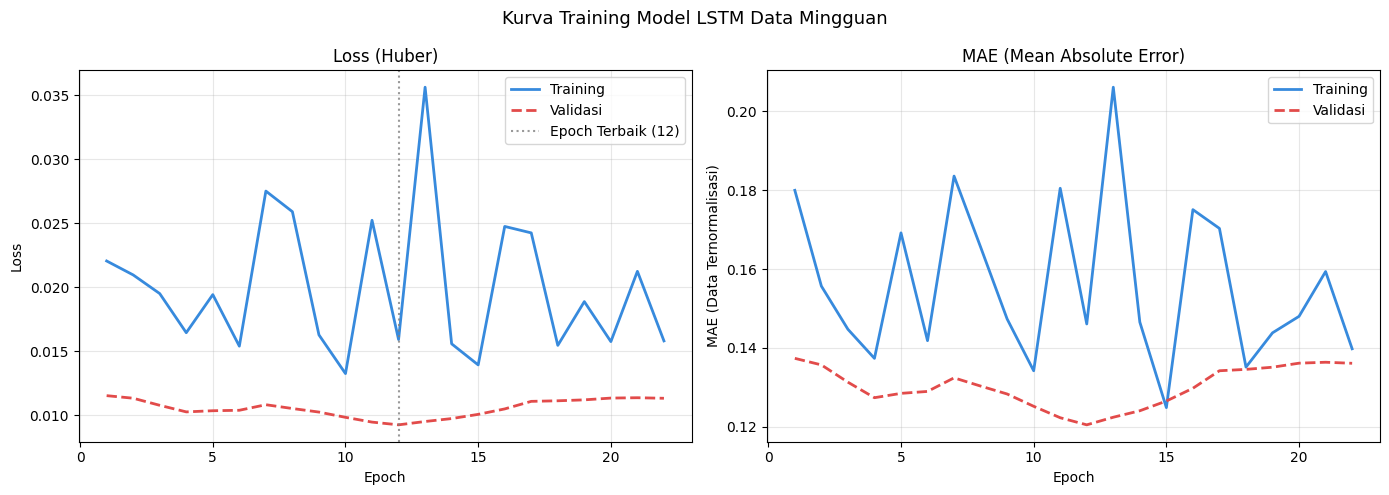

Visualisasi kurva training data mingguan selesai!


In [12]:
# ============================================================
# VISUALISASI HASIL TRAINING MODEL LSTM
# ============================================================

# Membuat kanvas dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Membuat urutan nomor epoch
ep = range(1, len(history.history['loss']) + 1)

# ============================================================
# 1. GRAFIK LOSS
# ============================================================

# Menampilkan loss data training
axes[0].plot(
    ep,
    history.history['loss'],
    label='Training',
    color='#378ADD',
    linewidth=2
)

# Menampilkan loss data validasi
axes[0].plot(
    ep,
    history.history['val_loss'],
    label='Validasi',
    color='#E24B4A',
    linewidth=2,
    linestyle='--'
)

# Menampilkan garis vertikal pada epoch terbaik
axes[0].axvline(
    best_epoch,
    color='gray',
    linestyle=':',
    alpha=0.8,
    label=f'Epoch Terbaik ({best_epoch})'
)

# Memberikan judul grafik
axes[0].set_title('Loss (Huber)', fontsize=12)

# Memberikan label sumbu
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Menampilkan legenda
axes[0].legend()

# Menampilkan grid
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. GRAFIK MAE
# ============================================================

# Menampilkan MAE data training
axes[1].plot(
    ep,
    history.history['mae'],
    label='Training',
    color='#378ADD',
    linewidth=2
)

# Menampilkan MAE data validasi
axes[1].plot(
    ep,
    history.history['val_mae'],
    label='Validasi',
    color='#E24B4A',
    linewidth=2,
    linestyle='--'
)

# Memberikan judul grafik
axes[1].set_title('MAE (Mean Absolute Error)', fontsize=12)

# Memberikan label sumbu
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (Data Ternormalisasi)')

# Menampilkan legenda
axes[1].legend()

# Menampilkan grid
axes[1].grid(True, alpha=0.3)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GRAFIK
# ============================================================

# Memberikan judul utama
plt.suptitle(
    'Kurva Training Model LSTM Data Mingguan',
    fontsize=13
)

# Mengatur tata letak grafik
plt.tight_layout()

# Menyimpan grafik ke file gambar
plt.savefig(
    'kurva_training_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

# Menampilkan grafik
plt.show()

# Menampilkan pesan bahwa proses visualisasi selesai
print('Visualisasi kurva training data mingguan selesai!')

## Sel 9 — Evaluasi pada Data Test

In [14]:
# ============================================================
# MELAKUKAN PREDIKSI PADA DATA TESTING
# ============================================================

# Menggunakan model LSTM yang telah dilatih
# untuk memprediksi konsentrasi plastik
# pada data testing.
y_pred_scaled = model.predict(
    X_test,
    verbose=0
)

# Mengembalikan hasil prediksi dari skala normalisasi
# (0–1) ke satuan aslinya yaitu partikel per meter kubik.
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Mengembalikan nilai target sebenarnya
# dari skala normalisasi ke skala asli.
y_true = scaler_y.inverse_transform(y_test)

# ============================================================
# MENGHITUNG METRIK EVALUASI
# ============================================================

# Mengubah array menjadi satu dimensi agar
# dapat dihitung menggunakan fungsi evaluasi.
y_pred_flat = y_pred.flatten()
y_true_flat = y_true.flatten()

# ------------------------------------------------------------
# ROOT MEAN SQUARE ERROR (RMSE)
# ------------------------------------------------------------

# RMSE mengukur rata-rata besar kesalahan prediksi.
# Semakin kecil nilai RMSE maka model semakin baik.
rmse = np.sqrt(
    mean_squared_error(
        y_true_flat,
        y_pred_flat
    )
)

# ------------------------------------------------------------
# MEAN ABSOLUTE ERROR (MAE)
# ------------------------------------------------------------

# MAE mengukur rata-rata selisih absolut
# antara nilai prediksi dan nilai sebenarnya.
# Nilai yang lebih kecil menunjukkan
# tingkat kesalahan yang lebih rendah.
mae = mean_absolute_error(
    y_true_flat,
    y_pred_flat
)

# ------------------------------------------------------------
# KOEFISIEN DETERMINASI (R²)
# ------------------------------------------------------------

# R² menunjukkan kemampuan model dalam
# menjelaskan variasi data target.
#
# Nilai R² mendekati 1 menunjukkan
# model memiliki performa yang sangat baik.
r2 = r2_score(
    y_true_flat,
    y_pred_flat
)

# ------------------------------------------------------------
# MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)
# ------------------------------------------------------------

# MAPE menunjukkan rata-rata persentase
# kesalahan prediksi terhadap nilai sebenarnya.
mape = (
    mean_absolute_percentage_error(
        y_true_flat,
        y_pred_flat
    ) * 100
)

# ============================================================
# MENAMPILKAN HASIL EVALUASI MODEL
# ============================================================

print('=' * 55)
print('      HASIL EVALUASI MODEL LSTM')
print('      Data Testing Mingguan')
print('=' * 55)

# Menampilkan nilai setiap metrik evaluasi.
print(f'RMSE  : {rmse:.2f} partikel/m³')
print(f'MAE   : {mae:.2f} partikel/m³')
print(f'MAPE  : {mape:.2f}%')
print(f'R²    : {r2:.4f}')

print('=' * 55)

# ============================================================
# INTERPRETASI NILAI R²
# ============================================================

# Memberikan interpretasi sederhana
# terhadap nilai koefisien determinasi.

if r2 >= 0.90:
    ket = 'Sangat Baik'

elif r2 >= 0.75:
    ket = 'Baik'

elif r2 >= 0.50:
    ket = 'Cukup'

else:
    ket = 'Perlu Perbaikan'

# Menampilkan hasil interpretasi.
print(f'Interpretasi R² : {ket}')

# ============================================================
# EVALUASI SETIAP MINGGU PREDIKSI
# ============================================================

# Menampilkan hasil evaluasi untuk setiap
# horizon prediksi secara terpisah.
print('\nEvaluasi Prediksi Mingguan')

# Membuat judul tabel hasil evaluasi.
print(f'{"Minggu":<10}{"RMSE":>12}{"MAE":>12}{"R²":>12}')

print('-' * 46)

# Menghitung metrik evaluasi pada setiap
# minggu prediksi.
for h in range(HORIZON):

    # Menghitung RMSE untuk minggu ke-h.
    rmse_h = np.sqrt(
        mean_squared_error(
            y_true[:, h],
            y_pred[:, h]
        )
    )

    # Menghitung MAE untuk minggu ke-h.
    mae_h = mean_absolute_error(
        y_true[:, h],
        y_pred[:, h]
    )

    # Menghitung nilai R² untuk minggu ke-h.
    r2_h = r2_score(
        y_true[:, h],
        y_pred[:, h]
    )

    # Menampilkan hasil evaluasi dalam bentuk tabel.
    print(
        f'{h+1:<10}'
        f'{rmse_h:>12.2f}'
        f'{mae_h:>12.2f}'
        f'{r2_h:>12.4f}'
    )

      HASIL EVALUASI MODEL LSTM
      Data Testing Mingguan
RMSE  : 72.50 partikel/m³
MAE   : 71.05 partikel/m³
MAPE  : 17.71%
R²    : -10.3597
Interpretasi R² : Perlu Perbaikan

Evaluasi Prediksi Mingguan
Minggu            RMSE         MAE          R²
----------------------------------------------
1                72.50       71.05    -10.3597


## Sel 10 — Visualisasi Prediksi vs Aktual

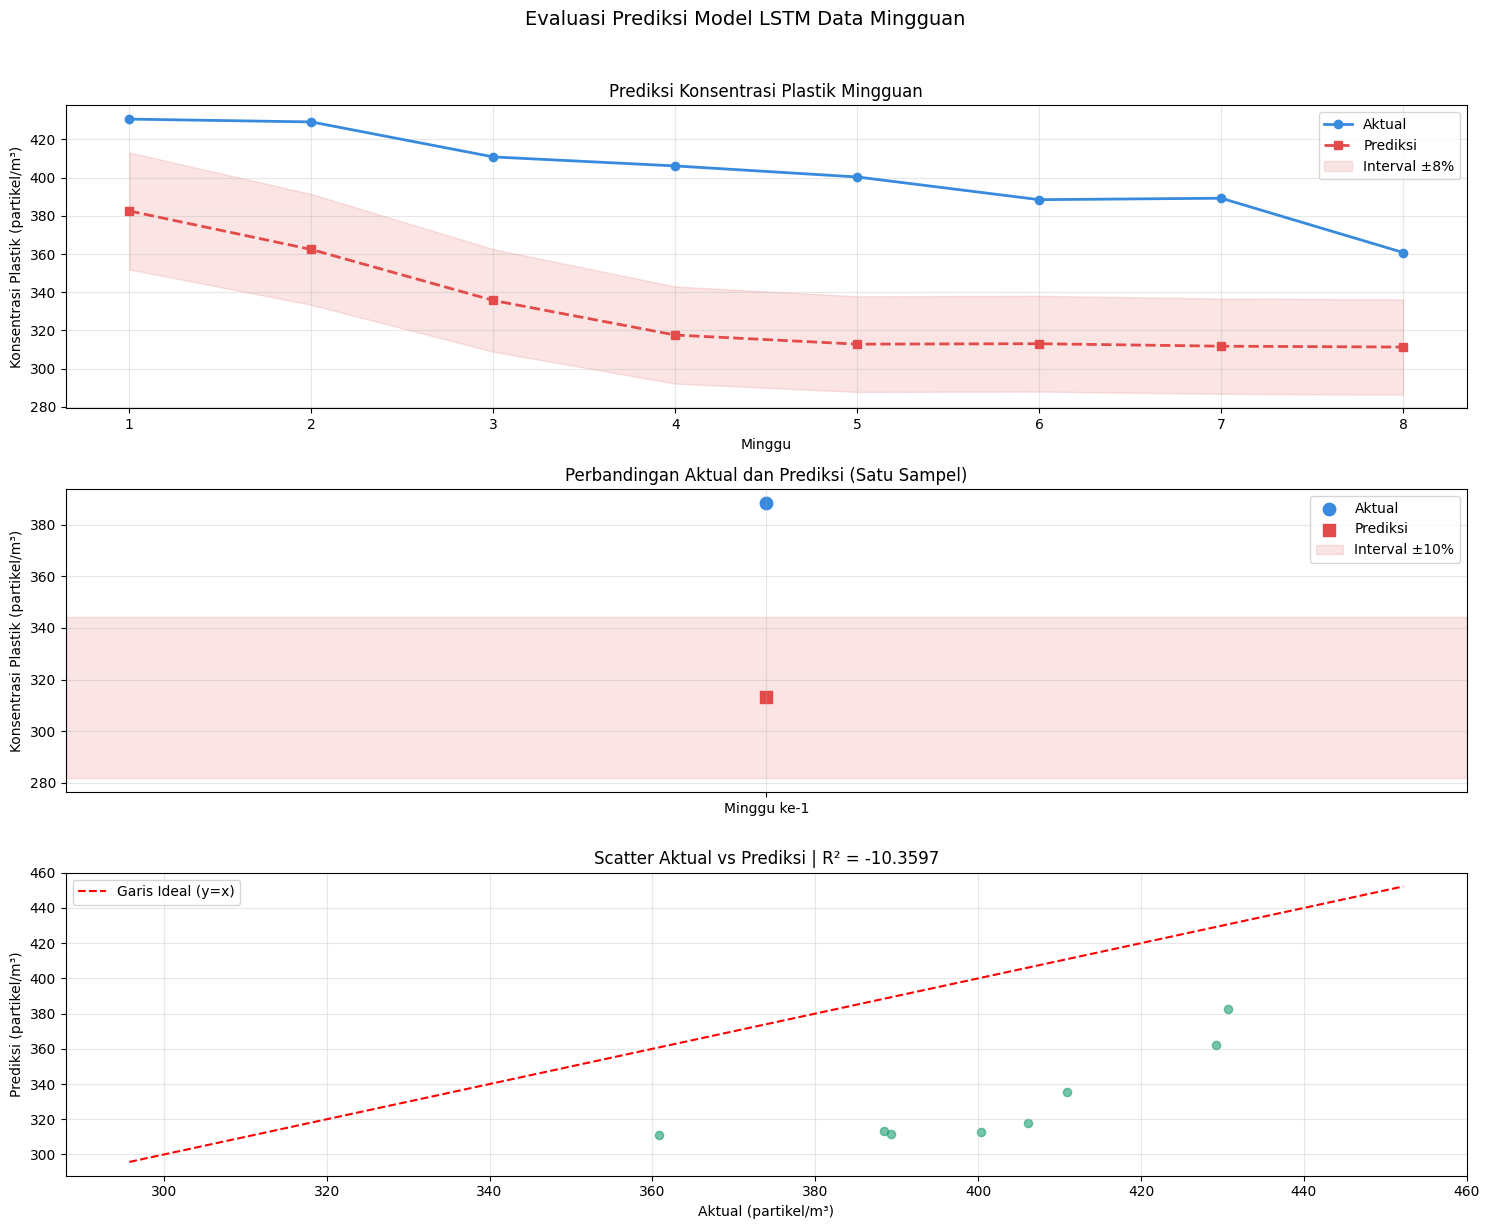

Visualisasi hasil prediksi selesai.


In [17]:
# ============================================================
# VISUALISASI HASIL PREDIKSI MODEL LSTM
# ============================================================

# Membuat sebuah kanvas (figure) yang terdiri atas
# tiga buah grafik yang disusun secara vertikal.
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ============================================================
# 1. GRAFIK HASIL PREDIKSI DATA MINGGUAN
# ============================================================

# Menentukan jumlah data yang akan ditampilkan.
# Maksimal ditampilkan sebanyak 12 minggu.
n_plot = min(12, len(y_true))

# Membuat sumbu-x berupa urutan minggu.
minggu = np.arange(1, n_plot + 1)

# Mengambil data aktual untuk ditampilkan.
y_true_plot = y_true[:n_plot, 0]

# Mengambil data hasil prediksi model.
y_pred_plot = y_pred[:n_plot, 0]

# Menampilkan grafik data aktual.
axes[0].plot(
    minggu,
    y_true_plot,
    marker='o',
    linewidth=2,
    color='#378ADD',
    label='Aktual'
)

# Menampilkan grafik hasil prediksi model.
axes[0].plot(
    minggu,
    y_pred_plot,
    marker='s',
    linestyle='--',
    linewidth=2,
    color='#E24B4A',
    label='Prediksi'
)

# Menambahkan area interval prediksi sebesar ±8%
# untuk memberikan gambaran rentang prediksi model.
axes[0].fill_between(
    minggu,
    y_pred_plot * 0.92,
    y_pred_plot * 1.08,
    color='#E24B4A',
    alpha=0.15,
    label='Interval ±8%'
)

# Memberikan judul grafik.
axes[0].set_title(
    'Prediksi Konsentrasi Plastik Mingguan',
    fontsize=12
)

# Memberikan label sumbu-x.
axes[0].set_xlabel('Minggu')

# Memberikan label sumbu-y.
axes[0].set_ylabel('Konsentrasi Plastik (partikel/m³)')

# Menampilkan legenda grafik.
axes[0].legend()

# Menambahkan garis bantu (grid).
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. PERBANDINGAN SATU SAMPEL PREDIKSI
# ============================================================

# Memilih salah satu contoh data untuk dibandingkan.
contoh_idx = min(5, len(y_true)-1)

# Menampilkan titik data aktual.
axes[1].scatter(
    1,
    y_true[contoh_idx,0],
    s=80,
    color='#378ADD',
    label='Aktual'
)

# Menampilkan titik hasil prediksi.
axes[1].scatter(
    1,
    y_pred[contoh_idx,0],
    s=80,
    color='#E24B4A',
    marker='s',
    label='Prediksi'
)

# Menampilkan interval prediksi sebesar ±10%.
axes[1].fill_between(
    [0.8,1.2],
    y_pred[contoh_idx,0]*0.90,
    y_pred[contoh_idx,0]*1.10,
    color='#E24B4A',
    alpha=0.15,
    label='Interval ±10%'
)

# Mengatur batas sumbu-x.
axes[1].set_xlim(0.8,1.2)

# Menentukan posisi label pada sumbu-x.
axes[1].set_xticks([1])

# Memberikan nama label sumbu-x.
axes[1].set_xticklabels(['Minggu ke-1'])

# Memberikan judul grafik.
axes[1].set_title(
    'Perbandingan Aktual dan Prediksi (Satu Sampel)',
    fontsize=12
)

# Memberikan label sumbu-y.
axes[1].set_ylabel('Konsentrasi Plastik (partikel/m³)')

# Menampilkan legenda.
axes[1].legend()

# Menambahkan grid.
axes[1].grid(True, alpha=0.3)

# ============================================================
# 3. SCATTER PLOT AKTUAL VS PREDIKSI
# ============================================================

# Menentukan jumlah titik yang akan ditampilkan
# agar grafik tetap mudah dibaca.
n_scatter = min(500, len(y_true_flat))

# Memilih data secara acak untuk ditampilkan
# pada scatter plot.
idx_scatter = np.random.choice(
    len(y_true_flat),
    n_scatter,
    replace=False
)

# Membuat scatter plot antara data aktual
# dan hasil prediksi model.
axes[2].scatter(
    y_true_flat[idx_scatter],
    y_pred_flat[idx_scatter],
    alpha=0.6,
    s=35,
    color='#1D9E75'
)

# Menentukan batas minimum grafik.
lim_min = min(
    y_true_flat.min(),
    y_pred_flat.min()
) * 0.95

# Menentukan batas maksimum grafik.
lim_max = max(
    y_true_flat.max(),
    y_pred_flat.max()
) * 1.05

# Membuat garis ideal (y = x).
# Apabila seluruh titik berada pada garis ini,
# maka hasil prediksi sama persis dengan data aktual.
axes[2].plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    'r--',
    linewidth=1.5,
    label='Garis Ideal (y=x)'
)

# Memberikan label sumbu-x.
axes[2].set_xlabel(
    'Aktual (partikel/m³)'
)

# Memberikan label sumbu-y.
axes[2].set_ylabel(
    'Prediksi (partikel/m³)'
)

# Memberikan judul grafik beserta nilai R².
axes[2].set_title(
    f'Scatter Aktual vs Prediksi | R² = {r2:.4f}',
    fontsize=12
)

# Menampilkan legenda.
axes[2].legend()

# Menambahkan grid.
axes[2].grid(True, alpha=0.3)

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GAMBAR
# ============================================================

# Memberikan judul utama pada keseluruhan gambar.
plt.suptitle(
    'Evaluasi Prediksi Model LSTM Data Mingguan',
    fontsize=14,
    y=1.02
)

# Mengatur tata letak grafik agar tidak saling bertumpuk.
plt.tight_layout()

# Menyimpan hasil visualisasi dalam format PNG
# dengan resolusi 150 dpi.
plt.savefig(
    'hasil_prediksi_lstm_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

# Menampilkan seluruh grafik ke layar.
plt.show()

# Menampilkan pesan bahwa proses visualisasi selesai.
print('Visualisasi hasil prediksi selesai.')

## Sel 11 — Analisis Residual & Distribusi Error

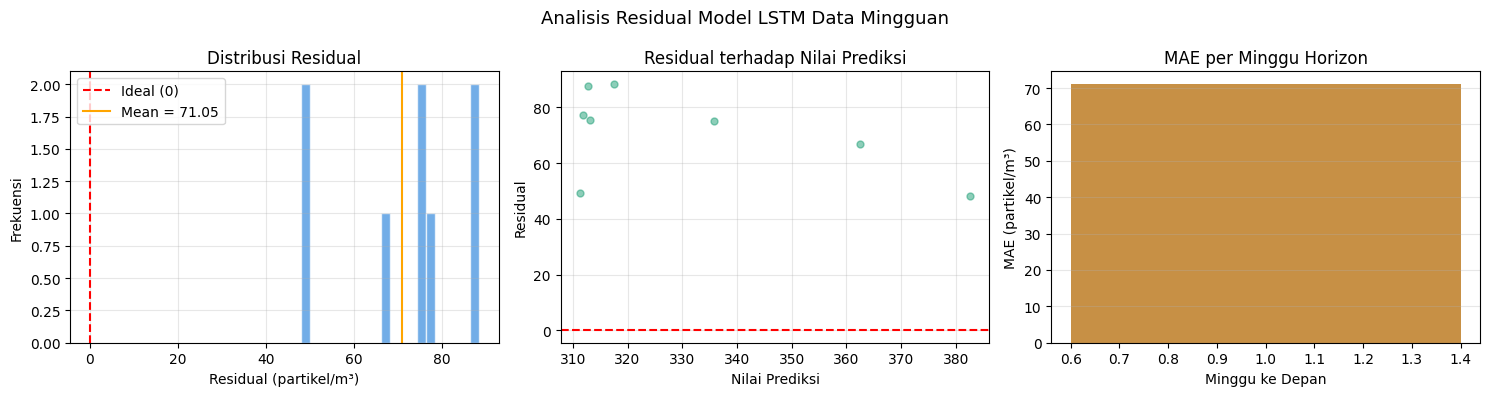


Statistik Residual
Mean Residual : 71.048
Standar Deviasi : 14.427
Residual Minimum : 48.087
Residual Maksimum : 88.536


In [19]:
# ============================================================
# ANALISIS RESIDUAL MODEL LSTM
# ============================================================

# Menghitung nilai residual, yaitu selisih antara
# nilai aktual dengan nilai hasil prediksi model.
#
# Residual = Aktual - Prediksi
#
# Nilai residual yang mendekati nol menunjukkan
# bahwa hasil prediksi model semakin akurat.
residual = y_true_flat - y_pred_flat

# Membuat sebuah kanvas yang terdiri atas
# tiga grafik dalam satu baris.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ============================================================
# 1. DISTRIBUSI RESIDUAL
# ============================================================

# Menampilkan histogram distribusi residual
# untuk melihat pola penyebaran kesalahan prediksi.
axes[0].hist(
    residual,
    bins=20,
    color='#378ADD',
    alpha=0.7,
    edgecolor='white'
)

# Menambahkan garis vertikal pada residual = 0.
# Garis ini menunjukkan kondisi prediksi yang ideal.
axes[0].axvline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--',
    label='Ideal (0)'
)

# Menambahkan garis rata-rata residual.
# Apabila mendekati nol berarti model memiliki bias
# yang relatif kecil.
axes[0].axvline(
    residual.mean(),
    color='orange',
    linewidth=1.5,
    label=f'Mean = {residual.mean():.2f}'
)

# Memberikan judul grafik.
axes[0].set_title('Distribusi Residual')

# Memberikan label sumbu-x.
axes[0].set_xlabel('Residual (partikel/m³)')

# Memberikan label sumbu-y.
axes[0].set_ylabel('Frekuensi')

# Menampilkan legenda.
axes[0].legend()

# Menambahkan garis bantu (grid).
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2. RESIDUAL TERHADAP HASIL PREDIKSI
# ============================================================

# Menentukan jumlah titik yang akan ditampilkan
# agar grafik tetap mudah dibaca.
n_scatter = min(500, len(y_pred_flat))

# Memilih sebagian data secara acak
# untuk ditampilkan pada scatter plot.
idx_scatter = np.random.choice(
    len(y_pred_flat),
    n_scatter,
    replace=False
)

# Membuat scatter plot antara nilai prediksi
# dan residual.
axes[1].scatter(
    y_pred_flat[idx_scatter],
    residual[idx_scatter],
    alpha=0.5,
    s=25,
    color='#1D9E75'
)

# Menambahkan garis horizontal pada residual = 0.
# Titik yang berada dekat garis ini menunjukkan
# kesalahan prediksi yang kecil.
axes[1].axhline(
    0,
    color='red',
    linewidth=1.5,
    linestyle='--'
)

# Memberikan judul grafik.
axes[1].set_title('Residual terhadap Nilai Prediksi')

# Memberikan label sumbu-x.
axes[1].set_xlabel('Nilai Prediksi')

# Memberikan label sumbu-y.
axes[1].set_ylabel('Residual')

# Menambahkan grid.
axes[1].grid(True, alpha=0.3)

# ============================================================
# 3. MAE SETIAP MINGGU HORIZON
# ============================================================

# Menghitung nilai Mean Absolute Error (MAE)
# untuk setiap horizon prediksi.
mae_per_horizon = [

    mean_absolute_error(
        y_true[:, h],
        y_pred[:, h]
    )

    for h in range(HORIZON)

]

# Membuat diagram batang MAE pada
# setiap minggu prediksi.
axes[2].bar(

    range(1, HORIZON + 1),

    mae_per_horizon,

    color='#BA7517',

    alpha=0.8

)

# Memberikan judul grafik.
axes[2].set_title('MAE per Minggu Horizon')

# Memberikan label sumbu-x.
axes[2].set_xlabel('Minggu ke Depan')

# Memberikan label sumbu-y.
axes[2].set_ylabel('MAE (partikel/m³)')

# Menambahkan grid pada sumbu-y.
axes[2].grid(True, alpha=0.3, axis='y')

# ============================================================
# MENAMPILKAN DAN MENYIMPAN GAMBAR
# ============================================================

# Memberikan judul utama pada seluruh grafik.
plt.suptitle(
    'Analisis Residual Model LSTM Data Mingguan',
    fontsize=13
)

# Mengatur tata letak agar grafik tidak saling bertumpuk.
plt.tight_layout()

# Menyimpan hasil visualisasi ke dalam
# file gambar berformat PNG.
plt.savefig(
    'analisis_residual_mingguan.png',
    dpi=150,
    bbox_inches='tight'
)

# Menampilkan seluruh grafik.
plt.show()

# ============================================================
# MENAMPILKAN STATISTIK RESIDUAL
# ============================================================

# Menampilkan ringkasan statistik residual
# untuk mengevaluasi performa model.
print('\nStatistik Residual')

print('=' * 40)

# Menampilkan rata-rata residual.
# Nilai yang mendekati nol menunjukkan
# model tidak memiliki bias yang besar.
print(f'Mean Residual : {residual.mean():.3f}')

# Menampilkan standar deviasi residual.
# Nilai yang kecil menunjukkan penyebaran
# kesalahan prediksi lebih konsisten.
print(f'Standar Deviasi : {residual.std():.3f}')

# Menampilkan residual terkecil.
print(f'Residual Minimum : {residual.min():.3f}')

# Menampilkan residual terbesar.
print(f'Residual Maksimum : {residual.max():.3f}')

print('=' * 40)

## Sel 12 — Fungsi Prediksi Real-Time (Inferensi)

Prediksi Konsentrasi Plastik Minggu Berikutnya
11-01-2026 : 307.21 partikel/m³   [SEDANG]


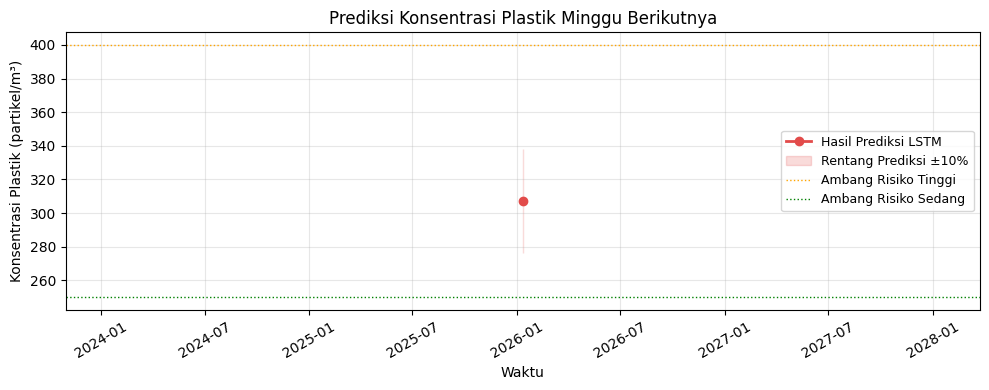


Visualisasi prediksi konsentrasi plastik mingguan berhasil dibuat.


In [21]:
# ============================================================
# FUNGSI PREDIKSI BERDASARKAN DATA TERBARU
# ============================================================

def prediksi_dari_data_terbaru(
    df_input,
    model,
    scaler_X,
    scaler_y,
    fitur_input,
    window=4,
    horizon=1
):
    """
    Melakukan prediksi konsentrasi plastik menggunakan
    data hidrodinamika mingguan terbaru.

    Parameter
    ----------
    df_input : DataFrame
        Dataset mingguan yang telah diproses.

    model : Model
        Model LSTM yang telah dilatih.

    scaler_X : MinMaxScaler
        Scaler untuk data input.

    scaler_y : MinMaxScaler
        Scaler untuk data target.

    fitur_input : list
        Daftar variabel input model.

    window : int
        Jumlah minggu yang digunakan
        sebagai data masukan model.

    horizon : int
        Jumlah minggu yang akan diprediksi.

    Return
    ------
    hasil_prediksi :
        Nilai prediksi konsentrasi plastik.

    waktu_prediksi :
        Waktu hasil prediksi.
    """

    # ============================================================
    # MEMASTIKAN DATA MENCUKUPI
    # ============================================================

    # Model membutuhkan minimal sejumlah data
    # sesuai ukuran window.
    if len(df_input) < window:
        raise ValueError(
            f'Data minimal {window} minggu diperlukan untuk melakukan prediksi.'
        )

    # ============================================================
    # MENGAMBIL DATA TERBARU
    # ============================================================

    # Mengambil data beberapa minggu terakhir
    # sesuai ukuran window.
    data_terbaru = df_input[fitur_input].values[-window:]

    # ============================================================
    # NORMALISASI DATA
    # ============================================================

    # Menormalisasi data menggunakan scaler
    # yang sama seperti saat training.
    data_ternormalisasi = scaler_X.transform(
        data_terbaru
    )

    # ============================================================
    # MENGUBAH BENTUK DATA
    # ============================================================

    # Mengubah bentuk data menjadi
    # (1, window, jumlah fitur).
    data_input = data_ternormalisasi.reshape(
        1,
        window,
        len(fitur_input)
    )

    # ============================================================
    # MELAKUKAN PREDIKSI
    # ============================================================

    # Melakukan prediksi menggunakan model LSTM.
    hasil_prediksi_normal = model.predict(
        data_input,
        verbose=0
    )

    # Mengembalikan hasil prediksi ke
    # skala aslinya.
    hasil_prediksi = scaler_y.inverse_transform(
        hasil_prediksi_normal
    )[0]

    # ============================================================
    # MEMBUAT WAKTU PREDIKSI
    # ============================================================

    # Mengambil tanggal terakhir
    # pada dataset.
    waktu_terakhir = df_input.index[-1]

    # Membuat tanggal prediksi
    # minggu berikutnya.
    waktu_prediksi = pd.date_range(
        start=waktu_terakhir + pd.Timedelta(weeks=1),
        periods=horizon,
        freq='W'
    )

    # Mengembalikan hasil prediksi
    # dan tanggal prediksi.
    return hasil_prediksi, waktu_prediksi


# ============================================================
# MELAKUKAN PREDIKSI MENGGUNAKAN DATA TERBARU
# ============================================================

hasil_prediksi, waktu_prediksi = prediksi_dari_data_terbaru(

    df_input=df_mingguan,

    model=model,

    scaler_X=scaler_X,

    scaler_y=scaler_y,

    fitur_input=FITUR_INPUT,

    window=WINDOW,

    horizon=HORIZON

)

# ============================================================
# MENAMPILKAN HASIL PREDIKSI
# ============================================================

print('=' * 60)
print('Prediksi Konsentrasi Plastik Minggu Berikutnya')
print('=' * 60)

# Menampilkan hasil prediksi beserta
# kategori tingkat risiko.
for waktu, nilai in zip(waktu_prediksi, hasil_prediksi):

    if nilai > 400:
        tingkat_risiko = 'TINGGI'

    elif nilai > 250:
        tingkat_risiko = 'SEDANG'

    else:
        tingkat_risiko = 'RENDAH'

    print(
        f'{waktu.strftime("%d-%m-%Y")} : '
        f'{nilai:.2f} partikel/m³   [{tingkat_risiko}]'
    )

# ============================================================
# MEMBUAT VISUALISASI HASIL PREDIKSI
# ============================================================

# Membuat kanvas grafik.
plt.figure(figsize=(10,4))

# Menampilkan grafik hasil prediksi.
plt.plot(

    waktu_prediksi,

    hasil_prediksi,

    marker='o',

    linewidth=2,

    color='#E24B4A',

    label='Hasil Prediksi LSTM'

)

# Menampilkan rentang prediksi ±10%.
#
# Rentang ini hanya bertujuan sebagai
# visualisasi sederhana, bukan confidence interval.
plt.fill_between(

    waktu_prediksi,

    hasil_prediksi * 0.90,

    hasil_prediksi * 1.10,

    alpha=0.20,

    color='#E24B4A',

    label='Rentang Prediksi ±10%'

)

# Menampilkan batas kategori
# risiko tinggi.
plt.axhline(

    400,

    color='orange',

    linewidth=1,

    linestyle=':',

    label='Ambang Risiko Tinggi'

)

# Menampilkan batas kategori
# risiko sedang.
plt.axhline(

    250,

    color='green',

    linewidth=1,

    linestyle=':',

    label='Ambang Risiko Sedang'

)

# Memberikan judul grafik.
plt.title(
    'Prediksi Konsentrasi Plastik Minggu Berikutnya',
    fontsize=12
)

# Memberikan label sumbu-x.
plt.xlabel('Waktu')

# Memberikan label sumbu-y.
plt.ylabel('Konsentrasi Plastik (partikel/m³)')

# Memutar label tanggal
# agar lebih mudah dibaca.
plt.xticks(rotation=30)

# Menampilkan legenda.
plt.legend(fontsize=9)

# Menampilkan garis bantu.
plt.grid(True, alpha=0.3)

# Mengatur tata letak grafik.
plt.tight_layout()

# Menyimpan grafik ke file PNG.
plt.savefig(

    'prediksi_mingguan.png',

    dpi=150,

    bbox_inches='tight'

)

# Menampilkan grafik.
plt.show()

# ============================================================
# MENAMPILKAN PESAN SELESAI
# ============================================================

print('\nVisualisasi prediksi konsentrasi plastik mingguan berhasil dibuat.')

## Sel 13 — Simpan Semua Hasil

In [23]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

# Mengimpor library JSON yang digunakan
# untuk menyimpan data dalam format JSON.
import json

# ============================================================
# MENYIMPAN MODEL LSTM
# ============================================================

# Menyimpan model LSTM yang telah selesai
# dilatih menggunakan format native Keras (.keras).
#
# Format ini merupakan format yang
# direkomendasikan pada Keras versi terbaru.
model.save(
    'lstm_hidrodinamika_mingguan_final.keras'
)

print('Model berhasil disimpan:')
print('lstm_hidrodinamika_mingguan_final.keras')

# ============================================================
# MENYIMPAN DATASET MINGGUAN
# ============================================================

# Menyimpan dataset hidrodinamika mingguan
# ke dalam file CSV agar dapat digunakan
# kembali tanpa perlu melakukan proses
# pengolahan data dari awal.
df_mingguan.to_csv(
    'data_hidrodinamika_mingguan.csv'
)

print('Dataset berhasil disimpan:')
print('data_hidrodinamika_mingguan.csv')

# ============================================================
# MENYIMPAN RIWAYAT PELATIHAN MODEL
# ============================================================

# Mengubah riwayat pelatihan model
# menjadi dictionary yang berisi nilai
# loss, validation loss, MAE,
# dan metrik lainnya pada setiap epoch.
riwayat_training = {

    nama: [

        float(nilai)

        for nilai in daftar_nilai

    ]

    for nama, daftar_nilai in history.history.items()

}

# Menyimpan riwayat pelatihan
# ke dalam file JSON.
with open(
    'riwayat_training.json',
    'w'
) as file:

    json.dump(
        riwayat_training,
        file,
        indent=2
    )

print('Riwayat pelatihan berhasil disimpan:')
print('riwayat_training.json')

# ============================================================
# MENYIMPAN METRIK EVALUASI
# ============================================================

# Membuat dictionary yang berisi
# seluruh hasil evaluasi model.
metrik_evaluasi = {

    'rmse_test': float(rmse),

    'mae_test': float(mae),

    'mape_test': float(mape),

    'r2_test': float(r2),

    'window': WINDOW,

    'horizon': HORIZON,

    'jumlah_fitur': n_fitur,

    'fitur_input': FITUR_INPUT

}

# Menyimpan metrik evaluasi
# ke dalam file JSON.
with open(
    'metrik_evaluasi.json',
    'w'
) as file:

    json.dump(
        metrik_evaluasi,
        file,
        indent=2
    )

print('Metrik evaluasi berhasil disimpan:')
print('metrik_evaluasi.json')

# ============================================================
# INFORMASI PENYIMPANAN KE GOOGLE DRIVE
# ============================================================

# Memberikan informasi kepada pengguna
# bahwa seluruh file dapat dipindahkan
# ke Google Drive apabila diperlukan.
print('\nApabila ingin menyimpan seluruh file ke Google Drive,')

print('jalankan sel penyimpanan Google Drive setelah sel ini.')

# ============================================================
# MENAMPILKAN RINGKASAN AKHIR
# ============================================================

print('\n' + '=' * 60)

print('RINGKASAN AKHIR MODEL LSTM')

print('=' * 60)

# Menampilkan informasi arsitektur model.
print(f'Model            : Bidirectional LSTM (32 → 16 → 8)')

# Menampilkan jumlah data mingguan.
print(f'Dataset          : {df_mingguan.shape[0]} minggu')

# Menampilkan jumlah fitur input.
print(f'Fitur Input      : {n_fitur} variabel')

# Menampilkan ukuran window.
print(f'Window           : {WINDOW} minggu')

# Menampilkan horizon prediksi.
print(f'Horizon          : {HORIZON} minggu ke depan')

print('\nHasil Evaluasi Model')

# Menampilkan nilai RMSE.
print(f'RMSE             : {rmse:.2f} partikel/m³')

# Menampilkan nilai MAE.
print(f'MAE              : {mae:.2f} partikel/m³')

# Menampilkan nilai MAPE.
print(f'MAPE             : {mape:.2f}%')

# Menampilkan nilai koefisien determinasi.
print(f'R²               : {r2:.4f}')

print('=' * 60)

# Menampilkan pesan bahwa seluruh proses
# telah selesai dilakukan.
print(
    'Seluruh proses pelatihan, evaluasi, '
    'dan penyimpanan model telah selesai.'
)

Model berhasil disimpan:
lstm_hidrodinamika_mingguan_final.keras
Dataset berhasil disimpan:
data_hidrodinamika_mingguan.csv
Riwayat pelatihan berhasil disimpan:
riwayat_training.json
Metrik evaluasi berhasil disimpan:
metrik_evaluasi.json

Apabila ingin menyimpan seluruh file ke Google Drive,
jalankan sel penyimpanan Google Drive setelah sel ini.

RINGKASAN AKHIR MODEL LSTM
Model            : Bidirectional LSTM (32 → 16 → 8)
Dataset          : 53 minggu
Fitur Input      : 11 variabel
Window           : 4 minggu
Horizon          : 1 minggu ke depan

Hasil Evaluasi Model
RMSE             : 72.50 partikel/m³
MAE              : 71.05 partikel/m³
MAPE             : 17.71%
R²               : -10.3597
Seluruh proses pelatihan, evaluasi, dan penyimpanan model telah selesai.


In [29]:
# ===== SIMPAN KE GOOGLE DRIVE (OPSIONAL) =====
from google.colab import drive
drive.mount('/content/drive')

import shutil
folder = '/content/drive/MyDrive/LSTM_Plastik_Hidrodinamika'
os.makedirs(folder, exist_ok=True)

for file in [
    'lstm_hidrodinamika_final.h5',
    'lstm_hidrodinamika_terbaik.h5',
    'data_hidrodinamika_sintetis.csv',
    'training_history.json',
    'metrik_evaluasi.json',
    'eda_hidrodinamika.png',
    'kurva_training.png',
    'hasil_prediksi_lstm.png',
    'analisis_residual.png',
    'prediksi_24jam.png',
]:
    if os.path.exists(file):
        shutil.copy(file, f'{folder}/{file}')
        print(f'Tersimpan: {folder}/{file}')

print('\nSemua file berhasil disimpan ke Google Drive!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/data_hidrodinamika_sintetis.csv
Tersimpan: /content/drive/MyDrive/LSTM_Plastik_Hidrodinamika/metrik_evaluasi.json

Semua file berhasil disimpan ke Google Drive!
